# Milestone 2 — EDA & Data Preparation
**IEEE-CIS Fraud Detection** | Machine Learning Spring 2026

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 40)
print("Libraries loaded.")

Libraries loaded.


## 2. Load & Merge Data

In [2]:
BUCKET = 'thomas-preiss-s3-bucket'

df_trn = pd.read_csv('data/train_transaction.csv', index_col=0)
df_idn = pd.read_csv('data/train_identity.csv',    index_col=0)

df = pd.merge(df_trn, df_idn, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
df.head(3)

Merged shape: (10000, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,...,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Code:** Loads both CSVs, left-joins on TransactionID so all transactions are kept even without identity data.

## 3. Exploratory Data Analysis
### 3a. Shape & Dtypes

In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes.value_counts())

Shape: (10000, 434)

float64    399
object      31
int64        4
Name: count, dtype: int64


### 3b. Missing Values

Columns with any missing: 327
  >80% missing: 190
  >50% missing: 248


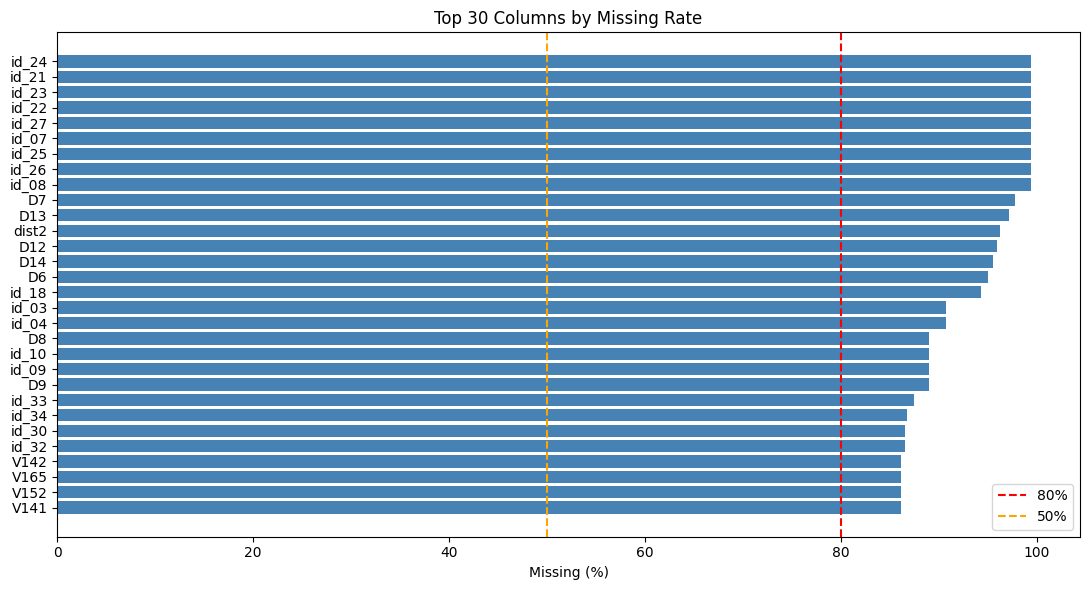

In [4]:
miss = (df.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
print(f"Columns with any missing: {len(miss)}")
print(f"  >80% missing: {(miss>80).sum()}")
print(f"  >50% missing: {(miss>50).sum()}")

top30 = miss.head(30)
fig, ax = plt.subplots(figsize=(11,6))
ax.barh(top30.index[::-1], top30.values[::-1], color='steelblue')
ax.axvline(80, color='red',    ls='--', lw=1.5, label='80%')
ax.axvline(50, color='orange', ls='--', lw=1.5, label='50%')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 30 Columns by Missing Rate')
ax.legend(); plt.tight_layout(); plt.show()

### 3c. Class Imbalance

Non-Fraud: 9,735  (97.35%)
Fraud    : 265  (2.65%)
Ratio    : 36.7:1


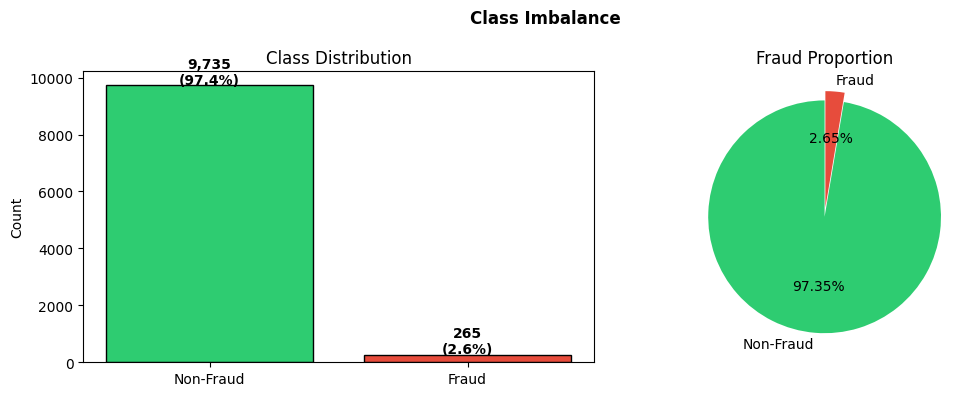

In [5]:
vc  = df['isFraud'].value_counts()
pct = df['isFraud'].value_counts(normalize=True)*100
print("Non-Fraud: {:,}  ({:.2f}%)".format(vc[0], pct[0]))
print("Fraud    : {:,}  ({:.2f}%)".format(vc[1], pct[1]))
print("Ratio    : {:.1f}:1".format(vc[0]/vc[1]))

fig, axes = plt.subplots(1,2, figsize=(11,4))
colors = ['#2ecc71','#e74c3c']
axes[0].bar(['Non-Fraud','Fraud'], vc.values, color=colors, edgecolor='black')
for i,(v,p) in enumerate(zip(vc.values, pct.values)):
    axes[0].text(i, v+50, "{:,}\n({:.1f}%)".format(v,p), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
axes[1].pie(vc.values, labels=['Non-Fraud','Fraud'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0,0.08))
axes[1].set_title('Fraud Proportion')
plt.suptitle('Class Imbalance', fontweight='bold'); plt.tight_layout(); plt.show()

⚠️ **~2.65% fraud rate (36:1 imbalance).** Standard accuracy is misleading — we use AUC, Precision, Recall, F1.

### 3d. Descriptive Statistics

In [6]:
key = ['TransactionAmt','card1','card2','addr1','C1','C2','D1','D4']
key = [c for c in key if c in df.columns]
print(df[key].describe().round(2).T.to_string())
print()
print("TransactionAmt by class:")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2).to_string())

                  count     mean      std     min     25%      50%       75%       max
TransactionAmt  10000.0   131.53   215.14     1.9    44.0    74.95    131.06   3247.91
card1           10000.0  9825.54  4776.77  1011.0  6381.0  9500.00  13780.00  18390.00
card2            9881.0   349.27   157.78   100.0   194.0   327.00    500.00    600.00
addr1            9087.0   292.44   103.68   110.0   204.0   299.00    330.00    536.00
C1              10000.0     8.40    34.57     0.0     1.0     1.00      3.00    735.00
C2              10000.0     7.93    34.41     0.0     1.0     1.00      3.00    808.00
D1              10000.0    96.69   145.97     0.0     0.0    10.00    151.00    634.00
D4               3769.0   167.73   179.50  -122.0     0.0    88.00    338.00    657.00

TransactionAmt by class:
          count    mean     std  min    25%    50%    75%      max
isFraud                                                           
0        9735.0  131.03  215.15  1.9  44.00  72.99  130.5

### 3e. Fraud Distribution Visualizations

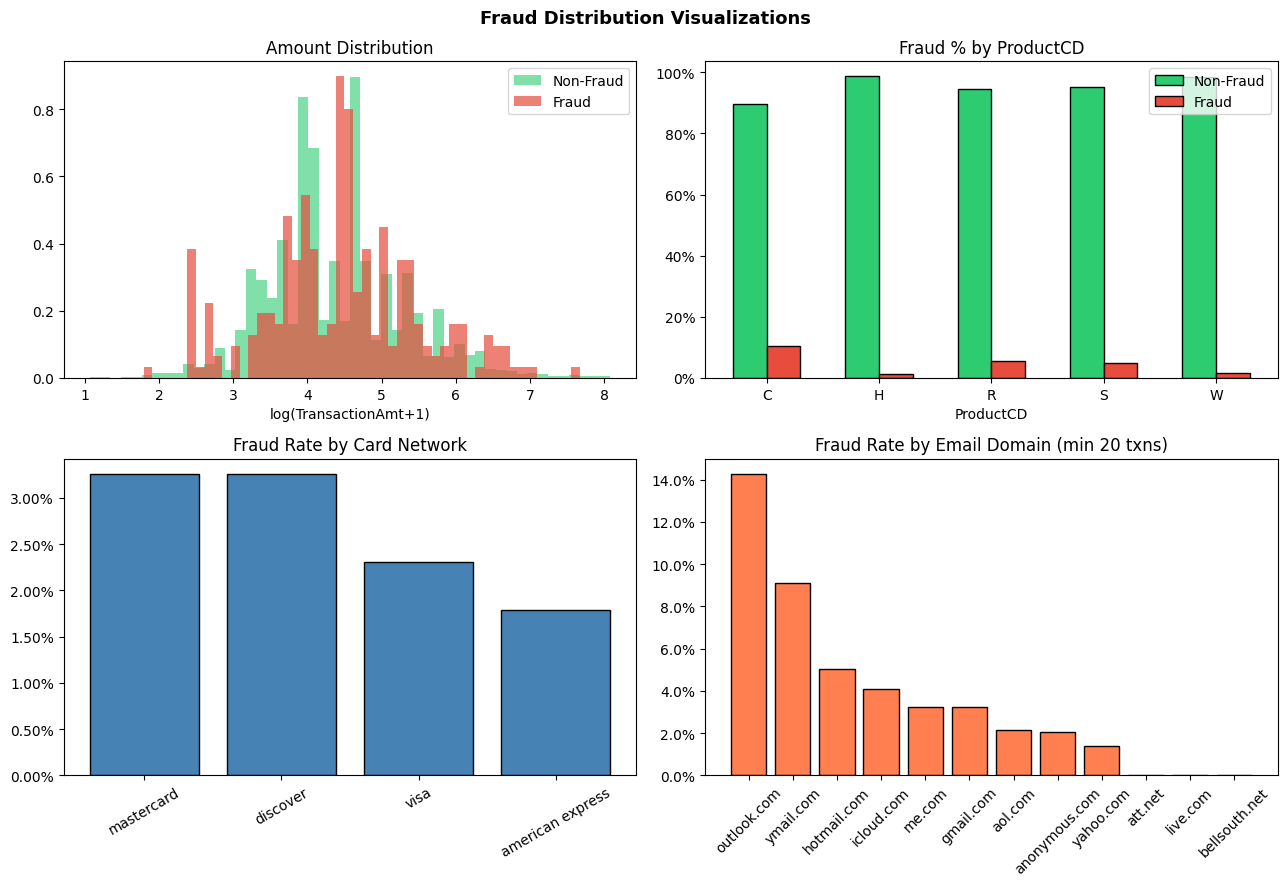

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

# 1 - Amount dist
fraud_a = df[df.isFraud==1]['TransactionAmt']
nfraud_a= df[df.isFraud==0]['TransactionAmt']
axes[0,0].hist(np.log1p(nfraud_a), bins=50, alpha=0.6, color='#2ecc71', label='Non-Fraud', density=True)
axes[0,0].hist(np.log1p(fraud_a),  bins=50, alpha=0.7, color='#e74c3c', label='Fraud',     density=True)
axes[0,0].set_xlabel('log(TransactionAmt+1)'); axes[0,0].set_title('Amount Distribution')
axes[0,0].legend()

# 2 - Product code
if 'ProductCD' in df.columns:
    pf = df.groupby(['ProductCD','isFraud']).size().unstack(fill_value=0)
    pf.div(pf.sum(1),axis=0).mul(100).plot(kind='bar', ax=axes[0,1],
        color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.6)
    axes[0,1].set_title('Fraud % by ProductCD'); axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0,1].tick_params(axis='x', rotation=0); axes[0,1].legend(['Non-Fraud','Fraud'])

# 3 - Card type
if 'card4' in df.columns:
    fr = df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)*100
    axes[1,0].bar(fr.index, fr.values, color='steelblue', edgecolor='black')
    axes[1,0].set_title('Fraud Rate by Card Network')
    axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1,0].tick_params(axis='x', rotation=30)

# 4 - Email domain
if 'P_emaildomain' in df.columns:
    em = df.groupby('P_emaildomain').agg(n=('isFraud','count'), f=('isFraud','sum'))
    em['rate'] = em['f']/em['n']*100
    top_em = em[em['n']>=20].sort_values('rate',ascending=False).head(12)
    axes[1,1].bar(top_em.index, top_em['rate'], color='coral', edgecolor='black')
    axes[1,1].set_title('Fraud Rate by Email Domain (min 20 txns)')
    axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Fraud Distribution Visualizations', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Data Cleaning

| Step | Description |
|------|-------------|
| **1** | Drop columns > 80% missing |
| **2** | Remove duplicate rows |
| **3** | Fix data types (M-flags T/F → 1/0) |
| **4** | Cap outliers in TransactionAmt (IQR) |
| **5** | Impute remaining missing values |

### Cleaning Step 1 — Drop High-Missing Columns (>80%)

In [8]:
df_c = df.copy()
drop_cols = df_c.columns[df_c.isnull().mean() > 0.80].tolist()
df_c = df_c.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns. Shape: {df_c.shape}")

Dropped 190 columns. Shape: (10000, 244)


Removes columns where >80% of values are missing — too sparse to impute reliably.

### Cleaning Step 2 — Remove Duplicates

In [9]:
before = len(df_c)
df_c = df_c.drop_duplicates()
print(f"Rows removed: {before - len(df_c)}. Shape: {df_c.shape}")

Rows removed: 0. Shape: (10000, 244)


Removes exact duplicate rows to prevent training bias.

### Cleaning Step 3 — Fix Data Types (M-columns T/F → 1/0)

In [10]:
m_cols = [c for c in df_c.columns if c.startswith('M')]
for col in m_cols:
    df_c[col] = df_c[col].map({'T':1,'F':0})
print(f"Converted {len(m_cols)} M-flag columns to binary integers.")
print(df_c[m_cols].dtypes.unique())

Converted 9 M-flag columns to binary integers.
[dtype('float64')]


M-columns are match flags (True/False). Converts them to 1/0 integers for ML models.

### Cleaning Step 4 — Cap Outliers in TransactionAmt

In [11]:
col = 'TransactionAmt'
Q1, Q3 = df_c[col].quantile(0.25), df_c[col].quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
n_out = ((df_c[col] < lo) | (df_c[col] > hi)).sum()
df_c[col] = df_c[col].clip(lo, hi)
print(f"Capped {n_out} outliers in {col}. New max: {df_c[col].max():.2f}")

Capped 572 outliers in TransactionAmt. New max: 392.23


Winsorizes extreme transaction amounts using 3×IQR — preserves row count while reducing skew.

### Cleaning Step 5 — Impute Remaining Missing Values

In [13]:
num_cols = df_c.select_dtypes(include=np.number).columns.difference(['isFraud'])
cat_cols = df_c.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if df_c[col].isnull().any():
        df_c[col] = df_c[col].fillna(df_c[col].median())
for col in cat_cols:
    if df_c[col].isnull().any():
        df_c[col] = df_c[col].fillna(df_c[col].mode()[0])

print(f"Missing after imputation: {df_c.isnull().sum().sum()}")

Missing after imputation: 10000


Fills remaining NaNs: median for numerics (robust to skew), mode for categoricals.

## 5. Feature Engineering

| Step | Description |
|------|-------------|
| **1** | Extract transaction hour |
| **2** | Extract day of week |
| **3** | Amount ratio vs. card mean |
| **4** | Label encode categoricals |
| **5** | Interaction: hour × amount |
| **6** | Log transform skewed features |
| **7** | Remove low-variance features |
| **8** | Remove secondary high-missing (>60%) |
| **9** | PCA on V-features |
| **10** | SelectKBest top 50 features |

### FE Step 1 — Transaction Hour

In [14]:
df_c['txn_hour'] = (df_c['TransactionDT'] % 86400) // 3600
print("txn_hour sample:", df_c['txn_hour'].value_counts().head(4).to_dict())

txn_hour sample: {0: 748, 17: 673, 1: 670, 19: 656}


Hour-of-day from the time delta — fraud often spikes at unusual hours.

### FE Step 2 — Day of Week

In [15]:
df_c['txn_day'] = (df_c['TransactionDT'] // 86400) % 7
print("txn_day dist:", df_c['txn_day'].value_counts().sort_index().to_dict())

txn_day dist: {1: 5122, 2: 3730, 3: 1148}


Day-of-week from the time delta — weekend vs. weekday fraud patterns differ.

### FE Step 3 — Amount Ratio vs. Card Mean

In [16]:
mean_by_card = df_c.groupby('card1')['TransactionAmt'].transform('mean')
df_c['amt_ratio'] = df_c['TransactionAmt'] / (mean_by_card + 1e-9)
print("amt_ratio — fraud mean:", df_c[df_c.isFraud==1]['amt_ratio'].mean().round(3),
      "| non-fraud mean:", df_c[df_c.isFraud==0]['amt_ratio'].mean().round(3))

amt_ratio — fraud mean: 1.129 | non-fraud mean: 0.996


A ratio >> 1 signals an unusually large charge for that cardholder — a key fraud indicator.

### FE Step 4 — Label Encode Categoricals

In [18]:
le = LabelEncoder()
cat_cols = df_c.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_c[col] = le.fit_transform(df_c[col].astype(str))
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}") 

Encoded 14 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'id_12', 'id_15', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']


Converts string columns to integer codes so all ML models can process them.

### FE Step 5 — Interaction Feature: Hour × Amount

In [19]:
df_c['hour_x_amt'] = df_c['txn_hour'] * df_c['TransactionAmt']
print("hour_x_amt created. Mean:", df_c['hour_x_amt'].mean().round(2))

hour_x_amt created. Mean: 1451.66


A large charge at 3 AM has a different risk profile than the same charge at noon.

### FE Step 6 — Log Transform Skewed Features

In [20]:
skew_thresh = 2.0
num_feats = df_c.select_dtypes(include=np.number).columns.difference(
    ['isFraud','TransactionID','txn_hour','txn_day'])
skewed = df_c[num_feats].skew().abs()
skewed_cols = skewed[skewed > skew_thresh].index[:8]  # cap at 8 for speed
for col in skewed_cols:
    if (df_c[col] >= 0).all():
        df_c[f'log_{col}'] = np.log1p(df_c[col])
print(f"Log-transformed {len(skewed_cols)} columns.")

Log-transformed 8 columns.


log1p normalizes right-skewed financial data — helps Logistic Regression and KNN.

### FE Step 7 — Remove Low-Variance Features

In [21]:
X_tmp = df_c.drop(columns=['isFraud'])
y_tmp = df_c['isFraud']
sel = VarianceThreshold(threshold=0.01)
sel.fit(X_tmp)
removed = X_tmp.columns[~sel.get_support()].tolist()
df_c = pd.concat([X_tmp.loc[:, sel.get_support()], y_tmp], axis=1)
print(f"Removed {len(removed)} low-variance cols. Shape: {df_c.shape}")

Removed 32 low-variance cols. Shape: (10000, 224)


Drops near-constant columns — they contribute no signal to any model.

### FE Step 8 — Remove Secondary High-Missing Columns (>60%)

In [22]:
drop2 = df_c.columns[df_c.isnull().mean() > 0.60].tolist()
df_c = df_c.drop(columns=drop2)
print(f"Removed {len(drop2)} cols with >60% missing. Shape: {df_c.shape}")

Removed 0 cols with >60% missing. Shape: (10000, 224)


Second pass for any remaining sparse columns — stricter than the 80% threshold in Cleaning Step 1.

### FE Step 9 — PCA on V-Features

In [23]:
v_cols = [c for c in df_c.columns if c.startswith('V')]
print(f"V-feature count: {len(v_cols)}")
if len(v_cols) >= 10:
    sc = StandardScaler()
    V_sc = sc.fit_transform(df_c[v_cols])
    pca = PCA(n_components=0.95, random_state=42)
    V_pca = pca.fit_transform(V_sc)
    pca_df = pd.DataFrame(V_pca,
                          columns=[f'pca_{i}' for i in range(V_pca.shape[1])],
                          index=df_c.index)
    df_c = df_c.drop(columns=v_cols)
    df_c = pd.concat([df_c, pca_df], axis=1)
    print(f"PCA: {len(v_cols)} V-cols → {V_pca.shape[1]} components (95% variance). Shape: {df_c.shape}")

V-feature count: 151


PCA: 151 V-cols → 51 components (95% variance). Shape: (10000, 124)


Compresses 339 correlated V-features into uncorrelated PCA components — reduces dimensionality.

### FE Step 10 — SelectKBest (Top 50 Features)

In [24]:
feat_cols = [c for c in df_c.columns if c not in ['isFraud','TransactionID','TransactionDT']]
X_all = df_c[feat_cols].fillna(0)
y_all = df_c['isFraud']
K = 50
skb = SelectKBest(f_classif, k=min(K, len(feat_cols)))
skb.fit(X_all, y_all)
selected = X_all.columns[skb.get_support()].tolist()
print(f"Selected {len(selected)} features via SelectKBest.")

top10 = pd.Series(skb.scores_, index=feat_cols).sort_values(ascending=False).head(10)
print("Top 10 by F-score:"); print(top10.round(1).to_string())

Selected 50 features via SelectKBest.
Top 10 by F-score:
C12          883.5
log_C12      860.1
C7           318.4
log_C10      316.1
id_17        277.5
card3        240.3
id_35        236.4
card6        210.8
ProductCD    151.6
id_01        145.6


Ranks features by ANOVA F-score vs. isFraud — keeps the 50 most predictive. Reduces noise before model training.

## 6. Save Processed Dataset

In [25]:
FINAL_COLS = selected + ['isFraud']
df_final = df_c[FINAL_COLS].copy()

import os
os.makedirs('data', exist_ok=True)
df_final.to_csv('data/df_processed.csv', index=False)
print(f"Saved data/df_processed.csv — shape: {df_final.shape}")
print(f"Fraud rate: {df_final.isFraud.mean()*100:.2f}%")

Saved data/df_processed.csv — shape: (10000, 51)
Fraud rate: 2.65%


✅ **Milestone 2 complete.** `df_processed.csv` is ready for model training in Milestone 3.